# 01a — Data Preparation: Library set

This notebook looks at the raw COCONUT compounds and find the overlaps with the DEPT-135 predicted version of the files to ensure data quality is maintianed.

## Imports

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib_venn import venn2
from tqdm import tqdm

from dept_similarity.constants import PROCESSED_DATA_DIR, RAW_DATA_DIR
from dept_similarity.utils import passed_cleanup, smiles_to_inchikey

tqdm.pandas()

# Loading and cleaning the predicted in-silico dataset

In [2]:
library_df = pd.read_parquet(
    f"{RAW_DATA_DIR}/dept_library.parquet",
    columns=[
        "identifier",
        "SMILES",
        "C_ppm_signed",
        "DEPT_intensity",
        "inchikey",
        "inchikey14",
    ],
)

library_df.head(2)

,identifier,SMILES,C_ppm_signed,DEPT_intensity,inchikey,inchikey14
0,dept_1000000_CVVMLCYWLCXJCW,CC1=CC(O)=CC(O)=C1O[C@@H]1O[C@H](CO)[C@@H](O)[...,16.314050;-62.056997;70.907458;74.956365;77.43...,0.17581119141624574;-0.1361119075237574;0.0964...,CVVMLCYWLCXJCW-HMUNZLOLSA-N,CVVMLCYWLCXJCW
1,dept_1000001_DTKRGJZNRMIPRF,O=C(OC[C@@H](O)[C@@H](O)[C@H](O)[C@H](O)CO)C1=...,-64.355224;-66.805444;71.308503;72.409067;72.4...,-0.13611190135208226;-0.1361119046807289;0.099...,DTKRGJZNRMIPRF-DDHJBXDOSA-N,DTKRGJZNRMIPRF


In [3]:
library_df["identifier"].nunique()

455930

In [4]:
# Convert the ";"-delimited peak columns to numeric arrays, aligned 1-to-1.
# C_ppm_signed: signed chemical shift (position; sign = multiplicity, CH2 negative).
# DEPT_intensity: predicted DEPT peak amplitude (also signed by multiplicity).
# Shifts are rounded to 2 dp as before; intensities kept at higher precision since
# their magnitudes are ~0.1 and downstream weighting is |intensity| / max|intensity|.
library_df["C_ppm_signed"] = library_df["C_ppm_signed"].apply(
    lambda x: [round(float(i), 2) for i in x.split(";")]
)
library_df["DEPT_intensity"] = library_df["DEPT_intensity"].apply(
    lambda x: [round(float(i), 6) for i in x.split(";")]
)

In [5]:
library_df.rename(
    columns={
        "C_ppm_signed": "signed_shifts",
        "DEPT_intensity": "dept_intensity",
        "SMILES": "smiles",
        "identifier": "compound_id",
    },
    inplace=True,
)

In [6]:
library_df["passed_cleanup"] = library_df["smiles"].progress_apply(passed_cleanup)

  0%|          | 0/455930 [00:00<?, ?it/s]

  0%|          | 859/455930 [00:00<00:53, 8580.29it/s]

  0%|          | 1721/455930 [00:00<00:52, 8601.98it/s]

  1%|          | 2597/455930 [00:00<00:52, 8670.23it/s]

  1%|          | 3477/455930 [00:00<00:51, 8717.66it/s]

...

100%|█████████▉| 453798/455930 [01:22<00:00, 5677.87it/s]

100%|█████████▉| 454366/455930 [01:22<00:00, 5658.82it/s]

100%|█████████▉| 454966/455930 [01:22<00:00, 5759.28it/s]

100%|█████████▉| 455543/455930 [01:22<00:00, 5701.98it/s]

100%|██████████| 455930/455930 [01:22<00:00, 5521.71it/s]

In [7]:
library_df["passed_cleanup"].value_counts()

passed_cleanup
True     455289
False       641
Name: count, dtype: int64

## Loading the COCONUT data

The data was downloaded on 20 May, 2026.

In [8]:
coconut_df = pd.read_csv(
    f"{RAW_DATA_DIR}/coconut_csv_lite-05-2026.csv.gz",
    usecols=["canonical_smiles"],
)
coconut_df.head(2)

,canonical_smiles
0,CO[C@@H]1C=C[C@]2(C3=CC4=C(C=C3CO)OCO4)[C@H](C...
1,CC(=O)OC1=CC(CO)=C2C(=O)C3=C(O)C(CC4=CC=CC(CO)...


## Check overlap across datasets

In [9]:
coconut_df["inchikey"] = coconut_df["canonical_smiles"].progress_apply(smiles_to_inchikey)
coconut_df["inchikey14"] = coconut_df["inchikey"].str[:14]

  0%|          | 0/738827 [00:00<?, ?it/s]

  0%|          | 179/738827 [00:00<06:54, 1783.11it/s]

  0%|          | 361/738827 [00:00<06:49, 1803.98it/s]

  0%|          | 542/738827 [00:00<06:55, 1777.90it/s]

  0%|          | 739/738827 [00:00<06:38, 1850.89it/s]

...

100%|█████████▉| 738242/738827 [06:34<00:00, 1763.39it/s]

100%|█████████▉| 738424/738827 [06:34<00:00, 1777.71it/s]

100%|█████████▉| 738603/738827 [06:34<00:00, 1746.00it/s]

100%|█████████▉| 738783/738827 [06:34<00:00, 1761.13it/s]

100%|██████████| 738827/738827 [06:34<00:00, 1873.30it/s]

In [10]:
# Subset to things that actually pass out filtering
coconut_df["passed_cleanup"] = coconut_df["canonical_smiles"].progress_apply(passed_cleanup)

  0%|          | 0/738827 [00:00<?, ?it/s]

  0%|          | 486/738827 [00:00<02:32, 4850.91it/s]

  0%|          | 1007/738827 [00:00<02:25, 5061.68it/s]

  0%|          | 1514/738827 [00:00<02:25, 5064.49it/s]

  0%|          | 2044/738827 [00:00<02:22, 5156.09it/s]

...

100%|█████████▉| 736823/738827 [02:25<00:00, 4993.73it/s]

100%|█████████▉| 737361/738827 [02:25<00:00, 5102.85it/s]

100%|█████████▉| 737874/738827 [02:25<00:00, 5109.23it/s]

100%|█████████▉| 738387/738827 [02:25<00:00, 4938.94it/s]

100%|██████████| 738827/738827 [02:25<00:00, 5065.60it/s]

In [11]:
coconut_df["passed_cleanup"].value_counts()

passed_cleanup
True     704074
False     34753
Name: count, dtype: int64

In [12]:
cleaned_coconut_df = coconut_df[coconut_df["passed_cleanup"]].copy()
cleaned_library_df = library_df[library_df["passed_cleanup"]].copy()

In [13]:
our_inchikey14s = set(cleaned_library_df["inchikey14"])
coconut_inchikey14s = set(cleaned_coconut_df["inchikey14"])
raw_coconut_inchikey14s = set(coconut_df["inchikey14"])

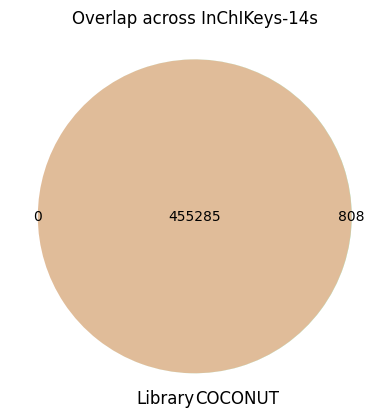

In [14]:
venn2(
    [our_inchikey14s, coconut_inchikey14s],
    set_labels=["Library", "COCONUT"],
)
plt.title("Overlap across InChIKeys-14s")
plt.show()

In [15]:
additional_in_library = our_inchikey14s - coconut_inchikey14s
if additional_in_library:
    print(f"Additional InChIKeys-14 in library: {len(additional_in_library)}")
else:
    print("No additional InChIKeys-14 in library compared to COCONUT.")

No additional InChIKeys-14 in library compared to COCONUT.


## Save the cleaned datasets

Cleaned datasets are those that pass data cleanup and can be found within the COCONUT database.

In [16]:
final_df = cleaned_library_df[cleaned_library_df["passed_cleanup"]].copy()
final_df = final_df[final_df["inchikey14"].isin(coconut_inchikey14s)].copy()

final_df.to_parquet(f"{PROCESSED_DATA_DIR}/library_data.parquet", index=False, engine="pyarrow")

In [17]:
len(final_df), final_df["inchikey14"].nunique()

(455289, 455285)